# 02 — Transformaciones: ¿cómo entra cada variable?


El notebook 01 dejó identificadas las variables candidatas y sus problemas de forma
funcional. Aquí se decide **con qué forma** entra cada una — un paso que tiene que
ocurrir antes de decidir **cuáles** entran (notebook 03): evaluar una variable en su
forma sin modificar puede esconder señal real, como ya se vio con `CADCONSTRUCTIONYEAR`
(notebook 01 §8). Todas las transformaciones están implementadas en
[`src/transformaciones.py`](../src/transformaciones.py) y este notebook las importa
directamente: los gráficos usan **exactamente el mismo código** que el pipeline del
notebook 04, no una reimplementación.

> ⚠️ Este notebook decide para modelos **lineales**. La §6 mide qué se traslada a
> árboles: casi nada.

In [2]:
import os, sys, warnings
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.limpieza import cargar_datos, limpiar_basico
from src.imputacion import fit_imputacion, aplicar_imputacion
from src.eda_utils import mean_por_grupo
from src import analisis_seleccion as asel
import src.transformaciones as tr

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)

df = cargar_datos()
df = limpiar_basico(df)
df = aplicar_imputacion(df, fit_imputacion(df))

y = np.log(df["PRICE"])
df["log_PRICE"] = y
print(f"{df.shape[0]:,} filas | objetivo: log(PRICE)")

75,469 filas | objetivo: log(PRICE)


## 1. El criterio: la forma de la relación, no la forma de la distribución

El reflejo habitual es "esta variable tiene mucha asimetría, le aplico un log". **Es el
criterio equivocado.** Lo que decide la transformación es la forma de
`E[log(PRICE) | X]`, no la forma marginal de `X`.

Para cada variable se compara su R² univariante contra el precio en tres formas —sin modificar, en log, y binnada
en 20 cuantiles— y además su **R² parcial** sobre un modelo que ya contiene los cuatro
*drivers* principales.

Estos *drivers* son las **cuatro variables con mayor \|spearman\| del notebook 01 §6**
(`CONSTRUCTEDAREA` 0,72; `indice_vulnerabilidad` 0,71; `alq_mediana_eur_m2_barrio` 0,67;
`BATHNUMBER` 0,67) — la quinta más alta, `CADASTRALQUALITYID` (0,60), queda fuera por un
margen claro. 

El R² parcial mide así cuánto aporta cada candidata **además de** la señal
marginal más fuerte ya disponible, en vez de confundirla con su propio efecto.

El binning en cuantiles actúa de **techo no paramétrico**: mide
cuánta señal habría si se permitiera *cualquier* forma, incluida una U.

In [5]:
base = ["CONSTRUCTEDAREA", "alq_mediana_eur_m2_barrio", "indice_vulnerabilidad", "BATHNUMBER"]
print(f"Modelo base (los 4 drivers): R² = {asel.r2_ols(df[base], y):.3f}")

candidatas = [
    "CONSTRUCTEDAREA", "indice_vulnerabilidad", "alq_mediana_eur_m2_barrio", "BATHNUMBER",
    "ROOMNUMBER", "DISTANCE_TO_CASTELLANA", "DISTANCE_TO_CITY_CENTER",
    "CADMAXBUILDINGFLOOR", "delitos_per_10k_barrio", "dist_espacio_deporte_m", "FLOORCLEAN",
    "CADDWELLINGCOUNT", "CADCONSTRUCTIONYEAR", "DISTANCE_TO_METRO",
    "dist_centro_medico_m", "dist_centro_educativo_m", "dist_parque_m",
    "CADASTRALQUALITYID"
]

formas = asel.comparar_formas_funcionales(df, y, candidatas, base=base)
print()
print(formas.round(4).to_string(index=False))

Modelo base (los 4 drivers): R² = 0.829

                 variable    skew  skew_log1p   r2_x  r2_logx  r2_bin  r2_parcial_bin forma_sugerida
          CONSTRUCTEDAREA  3.2612      0.5360 0.5626   0.5929  0.6385          0.0428            log
    indice_vulnerabilidad  0.5289      0.5259 0.4447   0.4448  0.4971          0.0020       tal cual
alq_mediana_eur_m2_barrio -0.0604     -0.2419 0.4503   0.4441  0.4861          0.0020       tal cual
               BATHNUMBER  2.5889      1.0727 0.4858   0.5088  0.5207          0.0205       tal cual
               ROOMNUMBER  6.0280     -0.8937 0.1915   0.1528  0.2707          0.0089        binning
   DISTANCE_TO_CASTELLANA  1.1323      0.1597 0.1337   0.1830  0.2346          0.0022        binning
  DISTANCE_TO_CITY_CENTER  0.5551     -0.4465 0.0734   0.0911  0.1876          0.0044        binning
      CADMAXBUILDINGFLOOR  1.7702     -0.0672 0.0703   0.0837  0.1455          0.0050        binning
   delitos_per_10k_barrio  6.0163      1.0307 0.00

La columna `forma_sugerida` aplica la regla con márgenes explícitos
(`src/analisis_seleccion.py`): el binning tiene que mejorar un **20%** relativo para
preferirlo, porque gasta 19 grados de libertad frente a 1 — una mejora pequeña no
compensa la pérdida de parsimonia. El log solo necesita un 5%, porque cuesta lo mismo
que la variable sin modificar.

Tres variables se apartan de ella tras evaluación:

In [ ]:
discrepancias = formas[formas.variable.isin(
    ["DISTANCE_TO_CASTELLANA", "DISTANCE_TO_CITY_CENTER", "CADDWELLINGCOUNT"]
)][["variable", "r2_x", "r2_logx", "r2_bin", "forma_sugerida"]].copy()
discrepancias["decision_del_plan"] = "log"
print(discrepancias.round(4).to_string(index=False))
print("\n-> en las tres, el techo del binning es más alto que el log, pero la relación")
print("   ya es log-lineal: el binning compra unas décimas de R² a cambio de 19")
print("   coeficientes en vez de 1. Se elige log por parsimonia e interpretabilidad")
print("   (una elasticidad se lee mejor que varios coeficientes).")

               variable   r2_x  r2_logx  r2_bin forma_sugerida decision_del_plan
 DISTANCE_TO_CASTELLANA 0.1292   0.1815  0.2351        binning               log
DISTANCE_TO_CITY_CENTER 0.0730   0.0914  0.1869        binning               log
       CADDWELLINGCOUNT 0.0080   0.0232  0.0604        binning               log

-> en las tres, el techo del binning es más alto que el log, pero la relación
   ya es log-lineal: el binning compra unas décimas de R² a cambio de 19
   coeficientes en vez de 1. Se elige log por parsimonia e interpretabilidad
   (una elasticidad se lee; 19 escalones no).


## 2. Contraejemplos a la lógica skew -> usar log

La tabla anterior contiene tres casos que demuestran que **la asimetría no predice la
decisión**:

In [4]:
ejemplos = formas[formas.variable.isin(
    ["alq_mediana_eur_m2_barrio", "delitos_per_10k_barrio", "CADCONSTRUCTIONYEAR"]
)][["variable", "skew", "r2_x", "r2_logx", "r2_bin", "forma_sugerida"]]
print(ejemplos.round(4).to_string(index=False))

                 variable    skew   r2_x  r2_logx  r2_bin forma_sugerida
alq_mediana_eur_m2_barrio -0.0275 0.4438   0.4368  0.4786       tal cual
   delitos_per_10k_barrio  6.0197 0.0072   0.0000  0.1638        binning
      CADCONSTRUCTIONYEAR -0.8062 0.0036   0.0038  0.0559        binning


1. **`alq_mediana_eur_m2_barrio`** es prácticamente simétrica (skew ≈ 0) y aplicarle log
   **empeora** el ajuste → se deja tal cual.
2. **`delitos_per_10k_barrio`** tiene asimetría fuerte, pero el log la deja **peor** que sin modificar:
   el problema no es la cola, es que la relación tiene forma de **U**.
3. **`CADCONSTRUCTIONYEAR`** es casi simétrica y sin embargo es donde el binning más
   aporta — multiplica el R² marginal por más de diez.

**Conclusión: se transforma por la forma de la relación con el objetivo, no por la forma
de la distribución marginal.**

## 3. Decisiones por variable

### 3.1 `CONSTRUCTEDAREA` → `log` + nudo en 50 m²

La relación es log-lineal en casi todo el rango, pero **se aplana en los pisos muy
pequeños**: por debajo de ~50 m² el €/m² se dispara y `log(PRICE)` deja de bajar al
mismo ritmo. Una sola pendiente no puede representar ese suelo de precio.

**Implementación: spline lineal de un nudo, dos columnas que entran juntas al modelo.**

- `log_area = log(CONSTRUCTEDAREA)` — pendiente por debajo del nudo.
- `log_area_50 = max(log_area - log(50), 0)` — vale 0 hasta 50 m² y crece por encima:
  es la corrección de pendiente para el tramo grande.

No es lo mismo que capar `log_area` en 50 m²: capar forzaría pendiente **cero** en un
tramo (el efecto de la superficie desaparecería ahí). Aquí cada tramo tiene su propia
pendiente, libre — por eso hace falta medir las dos columnas juntas, no una sola.

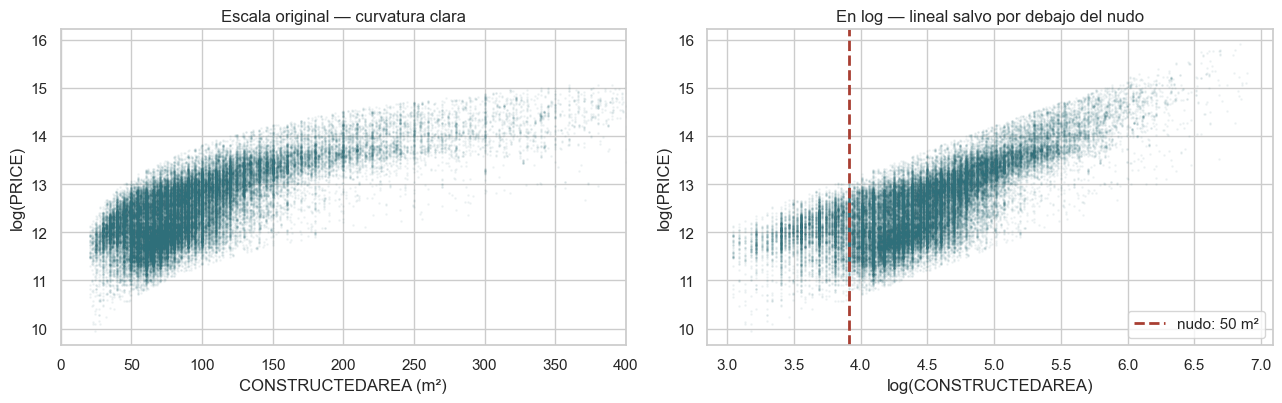

                    n  eur_por_m2  log_price_medio
tramo                                             
(0.0, 30.0]      1288      5000.0             11.8
(30.0, 40.0]     3439      4666.7             12.0
(40.0, 50.0]     5207      3791.7             12.0
(50.0, 60.0]     8408      2836.4             12.0
(60.0, 80.0]    18723      2446.2             12.1
(80.0, 120.0]   21938      3116.7             12.6
(120.0, 200.0]  11813      4107.4             13.3
(200.0, inf]     4987      4660.2             14.1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(df["CONSTRUCTEDAREA"], y, s=1, alpha=0.05, color="#2f6f7a")
axes[0].set_xlim(0, 400); axes[0].set_xlabel("CONSTRUCTEDAREA (m²)")
axes[0].set_ylabel("log(PRICE)"); axes[0].set_title("Escala original — curvatura clara")

la = np.log(df["CONSTRUCTEDAREA"].astype("float64"))
axes[1].scatter(la, y, s=1, alpha=0.05, color="#2f6f7a")
axes[1].axvline(np.log(50), color="#a83e32", linestyle="--", linewidth=2, label="nudo: 50 m²")
axes[1].set_xlabel("log(CONSTRUCTEDAREA)"); axes[1].set_ylabel("log(PRICE)")
axes[1].set_title("En log — lineal salvo por debajo del nudo"); axes[1].legend()

plt.tight_layout(); plt.show()

# medias por tramo para ver el aplanamiento
tramos = pd.cut(df["CONSTRUCTEDAREA"].astype("float64"),
                bins=[0, 30, 40, 50, 60, 80, 120, 200, np.inf])
resumen = df.assign(tramo=tramos).groupby("tramo", observed=True).agg(
    n=("PRICE", "size"),
    eur_por_m2=("PRICE", lambda s: (s / df.loc[s.index, "CONSTRUCTEDAREA"]).median()),
    log_price_medio=("log_PRICE", "mean"),
)
print(resumen.round(1).to_string())

In [6]:
df_area = tr._transformar_area(df.copy())
print("Columnas creadas:", [c for c in df_area.columns if c.startswith("log_area")])
print(f"\nR² solo log_area:                {asel.r2_ols(df_area[['log_area']], y):.4f}")
print(f"R² log_area + nudo en 50 m²:     {asel.r2_ols(df_area[['log_area', 'log_area_50']], y):.4f}")

Columnas creadas: ['log_area', 'log_area_50']

R² solo log_area:                0.5897
R² log_area + nudo en 50 m²:     0.6259


### 3.2 `CADCONSTRUCTIONYEAR` → binning por épocas constructivas

Correlación lineal con el precio prácticamente nula, y sin embargo mucha señal. La razón
se ve de un vistazo: **la relación tiene forma de U**.

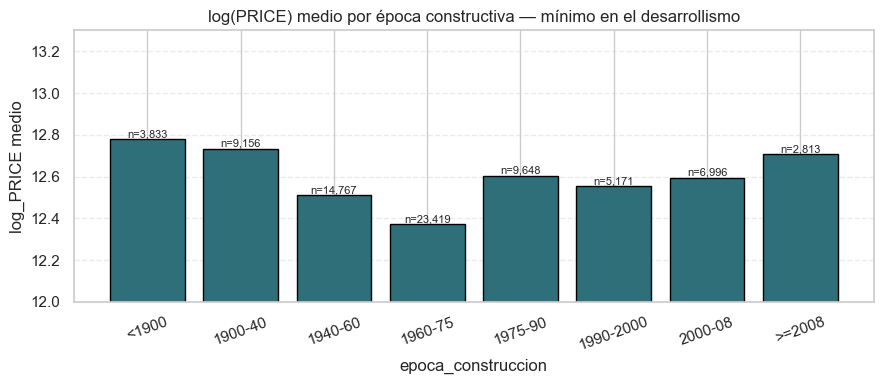

In [7]:
df_ep = tr._transformar_epoca(df.copy())
orden = ["<1900", "1900-40", "1940-60", "1960-75", "1975-90", "1990-2000", "2000-08", ">=2008"]

mean_por_grupo(df_ep, "log_PRICE", "epoca_construccion", order=orden, figsize=(9, 4), color="#2f6f7a")
plt.title("log(PRICE) medio por época constructiva — mínimo en el desarrollismo")
plt.xticks(rotation=20); plt.ylim(12.0, 13.3)
plt.tight_layout(); plt.show()

Lectura urbanística coherente: **histórico rehabilitado** (prima) → **desarrollismo
de los 60-70** (el mínimo) → **obra nueva** (prima). Una única pendiente lineal no puede
representar esta forma; el binning sí.

La categoría de referencia elegida es **`1960-75`**, el mínimo: así todos los
coeficientes de época salen positivos y se leen directamente como prima sobre el peor
tramo.

### 3.3 `ROOMNUMBER` → binning `0/1/2/3/4/5+`

Dos problemas que una pendiente continua no puede reproducir: **`0` no significa "sin
habitaciones"** (son estudios y lofts, y valen más que un 1 habitación), y hay un
**salto** entre 3 y 4.

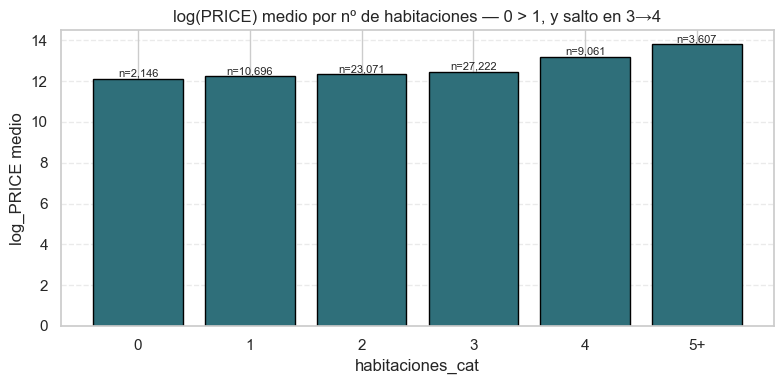

In [8]:
df_hab = tr._transformar_habitaciones(df.copy())
mean_por_grupo(df_hab, "log_PRICE", "habitaciones_cat", order=["0", "1", "2", "3", "4", "5+"],
               figsize=(8, 4), color="#2f6f7a")
plt.title("log(PRICE) medio por nº de habitaciones — 0 > 1, y salto en 3→4")
plt.tight_layout(); plt.show()

### 3.4 `FLOORCLEAN` → binning, con "sótano/bajo" como referencia

Mayor aporte parcial de toda la tabla de la §1. Se binna en cuatro tramos y se usa
`sotano/bajo` como categoría de referencia — así el efecto de planta baja queda
capturado en la referencia, sin necesidad de una binaria aparte (lo que el notebook 03
§5.1 comprobó que era redundante).

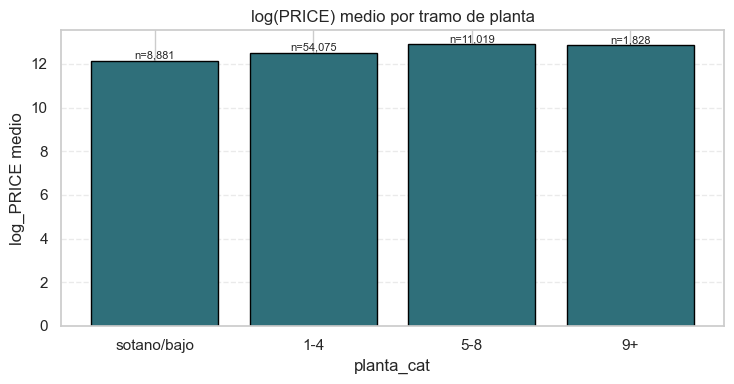

In [9]:
df_pl = tr._transformar_planta(df.copy())
mean_por_grupo(df_pl, "log_PRICE", "planta_cat", order=["sotano/bajo", "1-4", "5-8", "9+"],
               figsize=(7.5, 4), color="#2f6f7a")
plt.title("log(PRICE) medio por tramo de planta")
plt.tight_layout(); plt.show()

### 3.5 `CADMAXBUILDINGFLOOR` → binning **+ flag en 0**

`0` **no es una altura**: es "sin match catastral".
Y su precio medio es el **más alto** de toda la variable, así que tratarlo como altura
real invertiría la relación en el extremo inferior.

In [ ]:
cad = df["CADMAXBUILDINGFLOOR"].astype("float64")
comparacion = pd.DataFrame({
    "n": [(cad == 0).sum(), (cad != 0).sum()],
    "log_PRICE medio": [y[cad == 0].mean(), y[cad != 0].mean()],
    "PRICE medio (€)": [df.loc[cad == 0, "PRICE"].mean(), df.loc[cad != 0, "PRICE"].mean()],
}, index=["CADMAXBUILDINGFLOOR == 0 (flag de no match catastral)", "resto"])
print(comparacion.round(2).to_string())

df_alt = tr._transformar_altura_edificio(df.copy())
print(f"\nColumnas creadas: {['sin_match_catastral', 'alturaedif_cat']}")
print(f"Filas marcadas con el flag: {df_alt['sin_match_catastral'].sum():,}")

                                          n  log_PRICE medio  PRICE medio (€)
CADMAXBUILDINGFLOOR == 0 (centinela)     79            13.26        922088.61
resto                                 75724            12.54        386048.56

Columnas creadas: ['sin_match_catastral', 'alturaedif_cat']
Filas marcadas con el flag: 79


**Decisión: `sin_match_catastral` como flag explícito + binning del resto.** El flag
absorbe esas filas para que no contaminen la pendiente de altura.

(El notebook 03 acabó descartando `CADMAXBUILDINGFLOOR` del conjunto recomendado por
bajo aporte único; la transformación se mantiene implementada porque la variable sigue
disponible en la matriz completa.)

### 3.6 `delitos_per_10k_barrio` → quintiles

Relación en **U**, pero por una razón que no es causal: el distrito Centro acumula a la
vez la criminalidad más alta y los precios más altos. La U es **confusión con
centralidad**, no un efecto de la delincuencia sobre el precio.

In [ ]:
quintiles = pd.qcut(df["delitos_per_10k_barrio"], 5, labels=[f"Q{i}" for i in range(1, 6)])
df_q = df.assign(q=quintiles)

resumen = df_q.groupby("q", observed=True).agg(
    log_price_medio=("log_PRICE", "mean"),
    dist_centro_media_km=("DISTANCE_TO_CITY_CENTER", "mean"),
    n=("PRICE", "size"),
)
print(resumen.round(3).to_string())
print("\n-> el quintil más criminal es también el más céntrico: la U es confusión espacial.")

orden_q = [f"Q{i}" for i in range(1, 6)]
mean_por_grupo(df_q, "log_PRICE", "q", order=orden_q, color="#2f6f7a", figsize=(8, 4))
plt.title("log(PRICE) medio por quintil de delitos — forma de U")
plt.xlabel("quintil de delitos_per_10k_barrio")
plt.ylim(12.2, 12.8)
plt.tight_layout(); plt.show()

**Decisión: binning en quintiles, y se conserva solo como hallazgo narrativo**, no
como variable del conjunto recomendado (notebook 03 §6.3). Es el ejemplo más claro del
dataset de por qué una relación marginal no se puede leer como efecto.

> Los bordes de los quintiles son el **único corte de todo el plan que se estima sobre
> los datos**, así que se ajustan solo sobre train (§5).

### 3.7 Variables que no son modificadas

`alq_mediana_eur_m2_barrio` e `indice_vulnerabilidad` ya son simétricas y el log las empeora
(§2). Se **estandarizan** —no se transforman— porque `indice_vulnerabilidad` vive en un
rango muy pequeño y eso importa si el modelo se regulariza.

`BATHNUMBER` tiene relación casi lineal en `log(PRICE)`; solo se **capa en 5+** para que
la cola no arrastre la pendiente.

`CADASTRALQUALITYID` tiene relación no monótona, pero parece estar capturada por la propia categorización de la variable.

In [12]:
df_ban = tr._tope_banos(df.copy())
print("BATHNUMBER antes / después del tope:")
print(pd.DataFrame({
    "antes": df["BATHNUMBER"].value_counts().sort_index(),
    "después": df_ban["BATHNUMBER"].value_counts().sort_index(),
}).fillna(0).astype(int).to_string())

BATHNUMBER antes / después del tope:
            antes  después
BATHNUMBER                
0.0            71       71
1.0         43477    43477
2.0         24805    24805
3.0          5026     5026
4.0          1660     1660
5.0           572      764
6.0           116        0
7.0            24        0
8.0            16        0
9.0             6        0
10.0            7        0
11.0           14        0
12.0            2        0
13.0            2        0
14.0            2        0
16.0            1        0
18.0            1        0
20.0            1        0


## 4. Resumen ejecutable

| transformación | variables |
|---|---|
| **log** | `CONSTRUCTEDAREA` (+nudo 50 m²), `DISTANCE_TO_CASTELLANA`, `DISTANCE_TO_CITY_CENTER`, `DISTANCE_TO_METRO`, `CADDWELLINGCOUNT` |
| **binning** | `CADCONSTRUCTIONYEAR` (épocas), `ROOMNUMBER` (0/1/2/3/4/5+), `FLOORCLEAN` (ref. sótano/bajo), `CADMAXBUILDINGFLOOR` (+flag centinela), `delitos_per_10k_barrio` (quintiles) |
| **tal cual** | `alq_mediana_eur_m2_barrio`, `indice_vulnerabilidad` (estandarizar), `BATHNUMBER` (tope 5+) |

Todo ello implementado en `src/transformaciones.py`, expuesto por
`construir_matriz(df, familia, params)`.

In [ ]:
from src.transformaciones import fit_transformaciones, transformar_variables

X_base = df.drop(columns=["PRICE", "log_PRICE"])
params = fit_transformaciones(X_base)
X_lineal = transformar_variables(X_base, "lineal", params)

print(f"vía lineal: {X_lineal.shape[1]} columnas (antes de dummificar)")
print(f"  {sorted(X_lineal.columns.tolist())}")

vía lineal: 31 columnas (antes de dummificar)
  ['BATHNUMBER', 'BUILTTYPEID_1', 'BUILTTYPEID_2', 'CADASTRALQUALITYID', 'HASAIRCONDITIONING', 'HASBOXROOM', 'HASDOORMAN', 'HASGARDEN', 'HASLIFT', 'HASPARKINGSPACE', 'HASSWIMMINGPOOL', 'HASTERRACE', 'HASWARDROBE', 'ISDUPLEX', 'ISINTOPFLOOR', 'ISSTUDIO', 'alq_mediana_eur_m2_barrio', 'alturaedif_cat', 'delitos_q', 'epoca_construccion', 'es_sotano_bajo', 'habitaciones_cat', 'indice_vulnerabilidad', 'log_area', 'log_area_50', 'log_dist_castellana', 'log_dist_centro', 'log_dist_metro', 'log_viviendas_edif', 'planta_cat', 'sin_match_catastral']


## 5. Transformación para modelos tipo árbol

Todo lo decidido arriba responde a una limitación del **modelo lineal**: solo puede
representar relaciones aditivas y monótonas en cada variable. Un árbol no tiene esa
limitación, así que la mayoría de estas transformaciones dejan de tener sentido — y
algunas hacen daño.

In [ ]:
X_arboles = transformar_variables(X_base, "arboles", params)
print(f"vía árboles: {X_arboles.shape[1]} columnas (variables sin modificar)")
print(f"vía lineal:  {X_lineal.shape[1]} columnas (transformadas)")
print(f"\nÚnica coincidencia en el tratamiento: se descartan las mismas POI y orientaciones.")

vía árboles: 28 columnas (variables crudas)
vía lineal:  31 columnas (transformadas)

Única coincidencia en el tratamiento: se descartan las mismas POI y orientaciones.


| decisión del plan lineal | ¿se traslada a árboles? | por qué |
|---|---|---|
| objetivo `log(PRICE)` | **sí — lo único que se hereda** | no cambia los cortes, cambia la pérdida: optimiza error **relativo**, que es lo que interesa en tasación |
| `log` en las continuas | **no, es inerte** | una transformación monótona solo reetiqueta el punto de corte |
| binning | **no, hace daño** | se tira resolución que el árbol aprovecha mejor por su cuenta |
| flags centinela | **no** | el árbol aísla `== 0` con un único corte |
| estandarizar / topar `BATHNUMBER` | **no** | irrelevante para cortes |
| tratar la colinealidad | **no** | no degrada la predicción; solo reparte la importancia |


Por eso `src/transformaciones.py` ofrece **dos versiones de la transformación de variables**.

## 6. Aplicación sobre train/test

Casi todos los cortes de este plan son **umbrales fijos de dominio** (el nudo de 50 m²,
las épocas constructivas, los tramos de planta): no dependen de la distribución de los
datos, así que se aplican igual a train y a test sin ajuste previo.

**Solo dos elementos se estiman sobre los datos**, y por tanto solo esos dos pueden
filtrar información de test:

| elemento | qué se estima | dónde se ajusta |
|---|---|---|
| quintiles de `delitos_per_10k` | los bordes de `qcut` | `fit_transformaciones(train)` |
| estandarización | media y desviación | `fit_transformaciones(train)` |

Más la imputación del notebook 01 (mediana condicional de `FLOORCLEAN`, moda de
`CADASTRALQUALITYID`), que se ajusta con `fit_imputacion(train)`.

> En este notebook y en el 01 se ajustan sobre el dataset completo porque son
> documentos **exploratorios**. El pipeline real (notebook 04) hace el `split`
> **primero** y ajusta solo sobre train. Esa es la diferencia entre explorar y entrenar,
> y conviene que quede explícita en la memoria.

---

**Siguiente:** [`03_seleccion_variables.ipynb`](03_seleccion_variables.ipynb) — qué
variables entran.